Эпоха 0, Loss: 0.6865
Эпоха 1000, Loss: 0.3147
Эпоха 2000, Loss: 0.2392
Эпоха 3000, Loss: 0.2016
Эпоха 4000, Loss: 0.1753
Эпоха 5000, Loss: 0.1572
Эпоха 6000, Loss: 0.1413
Эпоха 7000, Loss: 0.1302
Эпоха 8000, Loss: 0.1211
Эпоха 9000, Loss: 0.1130
Точность на тестовых данных: 93.59%


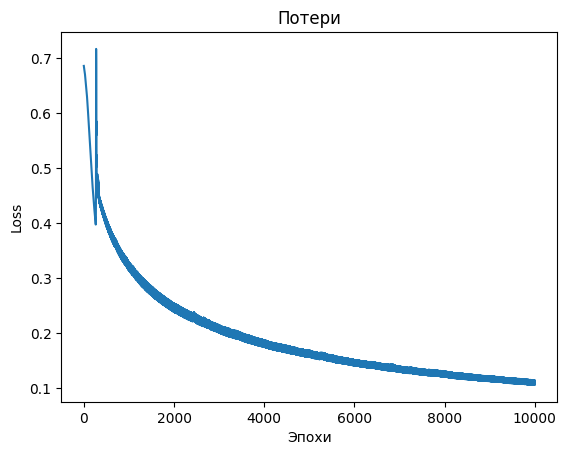

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/airline_delay.csv'
df = pd.read_csv(file_path)

df['target'] = (df['arr_del15'] / df['arr_flights'] > 0.15).astype(int)

features = ['arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
X = df[features].fillna(0)
y = df['target'].values.reshape(-1, 1)

X = (X - X.mean()) / X.std()

np.random.seed(42)
indices = np.arange(len(df))
np.random.shuffle(indices)
split_idx = int(0.8 * len(df))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train, X_test = X.iloc[train_idx].values, X.iloc[test_idx].values
y_train, y_test = y[train_idx], y[test_idx]

class AirlineClassifier:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.2
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.2
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        self.train_losses = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return np.where(z > 0, 1, 0)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y, output):
        m = X.shape[0]
        dZ2 = output - y

        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dZ1 = np.dot(dZ2, self.W2.T) * self.relu_derivative(self.A1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def backward(self, X, y, output):
        m = X.shape[0]
        error = output - y

        dZ2 = error
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dZ1 = np.dot(dZ2, self.W2.T) * self.relu_derivative(self.A1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def train(self, X, y, epochs=5000):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            loss = -np.mean(y * np.log(output + 1e-9) + (1 - y) * np.log(1 - output + 1e-9))
            self.train_losses.append(loss)

            if epoch % 1000 == 0:
                print(f"Эпоха {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

model = AirlineClassifier(input_size=len(features), hidden_size=8, output_size=1)
model.train(X_train, y_train, epochs=10000)

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Точность на тестовых данных: {accuracy * 100:.2f}%")

plt.plot(model.train_losses)
plt.title("Потери")
plt.xlabel("Эпохи")
plt.ylabel("Loss")
plt.show()